<a href="https://colab.research.google.com/github/jkf87/jev-handson/blob/main/01_Jev%E1%84%92%E1%85%A9%E1%84%8E%E1%85%AE%E1%86%AF3%E1%84%80%E1%85%A1%E1%84%8C%E1%85%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jev 호출 3가지: noul · choice · score

Jev는 글을 쓰는 대신 **닫힌 질문에 확률로 답하는** 모델이에요. 이 노트북에서는 질문 종류 세 가지를 하나씩 불러 보고, 마지막에 세 질문을 한 번에 보내 봐요.

| 질문 종류 | 무엇을 묻나요 | 돌아오는 값 |
|---|---|---|
| **noul** | 예/아니오 | 예일 확률 (0~1) |
| **choice** | 보기 중 하나 고르기 | 고른 보기 + 보기별 확률 |
| **score** | 순서 있는 단계 매기기 | 단계의 기대값 + 단계별 확률 |

- 런타임은 **CPU면 충분해요**(GPU 필요 없어요). 위에서부터 차례로 ▶ 실행하면 돼요.
- 키가 없어도 끝까지 돌아가요. 그때는 강사가 미리 받아 둔 응답을 보여 드려요(replay 모드).

## 1. 설정

왼쪽 🔑(보안 비밀) 메뉴에 키를 넣고 "노트북 액세스"를 켜 주세요. 키 이름은 아래와 같아요.

- TypeSafe로 부를 때: `TYPESAFE_API_KEY`
- OpenRouter로 부를 때: `OPENROUTER_API_KEY`

키 값은 화면에 절대 출력하지 않아요. "있음/없음"만 보여 드려요.

In [1]:
#@title 어디로 부를지 고르기
PROVIDER = "typesafe" #@param ["typesafe", "openrouter"]
FORCE_REPLAY = False #@param {type:"boolean"}
# FORCE_REPLAY를 켜면 키가 있어도 기록된 응답만 보여 줘요(강의 화면용).

In [ ]:
#@title 기록된 응답 불러오기 (키가 없을 때 써요)
# 강사가 미리 실행해서 받아 둔 Jev·GLM 응답이에요. API 키는 들어 있지 않아요.
# 키가 없으면 이 기록으로 결과를 보여 드려요(replay 모드).
import base64, gzip, json
REPLAY_B64 = "H4sIAAAAAAAC/91X227bMAz9lcLPW0Dqzr4O2CfstZBkKfOW2EXibCiK/PtkJ03sLLWTzs2wPeQihpZODnlE8jn7Fn7cA3dGO0XaSiFRqez+7jl7WK7TJ2Pw4S6z5fpnWK1be1xt1vXK1kVVtmtflbHIQ+lDWsKMUfJfhHko8/ZnSO/ZJ7tYZsmOzeLzfoOQNybWmL6E1dOdLeerp2ybbI+ryllXLIq6COvDLjCD/RYwE3r/KMwkbx5Z+2rVAMC0Tsv66bFZ7c2NQx3scof3a1W0WLN0wqIo5w2K3p/A9qDfQbz4v3iUVRkOuNZ20brtVnXwX8vC28XOsu1A2p/fmDarRFPd7l1Wm50viY5va902rssqD41DE6+POEM+gwb3Zm3nod2gKB839UNdfQ9lA0NCs0+1qXtWrdvN2pg7iEYjKWGtyZXrxhzkSczPAQWaBCgX6gxQBkegHlxO0pnokRsuukA5XgCU1ERA9TBQpOA8s+iNZtIBdoGKq1S0S693ERF2RAQHDUFXQvsM7ivoTYzxc6FFOjDGpHdgUQOHmKIcu4ypU8bOCHinuVP5pojTiH7hdf3ipfp9EyMkzzAi5JERq5zlgXmP3ikWr0525NMku2TDyc65FM5rlVsyDGIPKF5yfRCbCCiMAPVa8OgVkAWRs15t42I8x46ZcH2ZgGvKBE6ZZmo4zTRy8NpZiWDByl70hBwn5e9WzrdQIoCPUMKQQSBNpGNQvHd7t2IYTWicKKH5cEJrKU3E9MoF5yl4vWZNXQDU6ImAjhRurSJIEaIW2oDVoQNUKHldV6nxFl0l0qEiGux3lQYnqokChmui9gBouZGgZfrKuuHV+pI8FBOFVwyH1+popA+KiQiBBz+YhyPhpRsMDfhav4Pn+p1/aGKQbKKJAYcnBidzSn2BIQa5iaJ3Q/IrA87NTaZEPE6JdDIl0lR6lsN6zilSCEJpTUEwnXdY4wqvY82od2SNDrQRvjYYEN5oMsh9JJCYOmBlDIu9ywUvmAxaof1hw4a36064EcPdSRTesqCCM+RCZDQ4W/4XDRtva8I5Sra/AM2NZ2O1EgAA"
REPLAY = json.loads(gzip.decompress(base64.b64decode(REPLAY_B64)).decode("utf-8")) if REPLAY_B64 else {}
print(f"기록된 응답 {len(REPLAY)}개를 불러왔어요.")

기록된 응답 18개를 불러왔어요.


In [2]:
#@title 키 확인과 실행 모드
import os

def get_secret(name):
    """Colab 보안 비밀 → 환경 변수 순서로 키를 찾아요. 값은 절대 출력하지 않아요."""
    try:
        from google.colab import userdata
        value = userdata.get(name)
        if value:
            return value.strip()
    except Exception:
        pass
    return os.environ.get(name, "").strip()

KEY_NAME = {"typesafe": "TYPESAFE_API_KEY", "openrouter": "OPENROUTER_API_KEY"}[PROVIDER]
JEV_KEY = get_secret(KEY_NAME)
MODE = "live" if (JEV_KEY and not FORCE_REPLAY) else "replay"
print(f"Jev 제공처: {PROVIDER}  |  {KEY_NAME}: {'있음' if JEV_KEY else '없음'}")
if MODE == "live":
    print("Jev 실행 모드: 실시간 호출(live)이에요.")
else:
    print("Jev 실행 모드: 기록 재생(replay)이에요. 강사가 미리 받아 둔 응답을 보여 드려요.")

Jev 제공처: typesafe  |  TYPESAFE_API_KEY: 있음
Jev 실행 모드: 실시간 호출(live)이에요.


In [3]:
#@title 그래프 한글 글꼴 준비 (Colab이면 나눔고딕을 설치해요)
import os, subprocess, warnings
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def setup_korean_font():
    nanum = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    if IN_COLAB and not os.path.exists(nanum):
        subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null 2>&1", shell=True)
        if not os.path.exists(nanum):
            subprocess.run("apt-get -qq update > /dev/null 2>&1 && apt-get -qq install -y fonts-nanum > /dev/null 2>&1", shell=True)
    if os.path.exists(nanum):
        fm.fontManager.addfont(nanum)
    names = {f.name for f in fm.fontManager.ttflist}
    for name in ["NanumGothic", "AppleGothic", "Apple SD Gothic Neo", "Malgun Gothic", "Noto Sans CJK KR", "Noto Sans KR"]:
        if name in names:
            plt.rcParams["font.family"] = name
            plt.rcParams["axes.unicode_minus"] = False
            return name
    warnings.filterwarnings("ignore", message="Glyph")
    return None

font = setup_korean_font()
print("그래프 글꼴:", font or "한글 글꼴을 못 찾았어요(글자가 네모로 보일 수 있어요)")

그래프 글꼴: NanumGothic


## 2. Jev를 부르는 함수 `jev()`

`jev(state, questions)` 하나로 모든 질문을 보내요. **state**에는 판단에 필요한 사실을, **questions**에는 묻고 싶은 질문을 이름 붙여 넣어요. 응답의 `answers[질문 이름]`에 답이 들어 있어요.

TypeSafe와 OpenRouter는 요청 모양이 같고 주소와 모델 이름만 달라요. 429·5xx면 한 번 다시 시도하고, 401·403·422는 한국어로 이유를 알려 줘요.

In [4]:
import hashlib, json, time
import requests

ENDPOINTS = {
    "typesafe":   ("https://api.typesafe.ai/v1/systemone",        "jev-latest"),
    "openrouter": ("https://openrouter.ai/api/alpha/decisions",   "~typesafe/jev-latest"),
}
CALLS = []  # 호출 기록(종류, 걸린 시간, 입력 토큰) — 마지막에 요약해요

class JevError(Exception):
    """Jev 호출이 실패했을 때 나는 오류예요."""

class ReplayMissing(JevError):
    """replay 모드인데 기록에 없는 요청일 때 나는 오류예요."""

def _key(*parts):
    text = json.dumps(parts, ensure_ascii=False, sort_keys=True)
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:16]

def jev(state, questions):
    """Jev에 질문을 보내고 응답(JSON)을 돌려줘요. 응답의 '_ms'는 걸린 시간(밀리초)이에요."""
    k = "jev:" + _key(state, questions)
    if MODE == "replay":
        if k not in REPLAY:
            raise ReplayMissing("키가 없어서 기록된 요청만 볼 수 있어요. 키를 넣으면 어떤 문장이든 판단해요.")
        data = json.loads(json.dumps(REPLAY[k]))
    else:
        url, model = ENDPOINTS[PROVIDER]
        headers = {"Authorization": f"Bearer {JEV_KEY}", "Content-Type": "application/json",
                   "User-Agent": "jev-colab/1.0"}  # 기본 User-Agent는 403으로 막혀요
        body = {"model": model, "state": state, "questions": questions}
        for attempt in (1, 2):  # 429·5xx면 한 번만 다시 시도해요
            t0 = time.time()
            try:
                r = requests.post(url, headers=headers, json=body, timeout=30)
            except requests.RequestException as e:
                if attempt == 1:
                    time.sleep(1.5); continue
                raise JevError(f"네트워크 오류로 Jev에 닿지 못했어요: {type(e).__name__}") from None
            ms = round((time.time() - t0) * 1000)
            if (r.status_code == 429 or r.status_code >= 500) and attempt == 1:
                time.sleep(1.5); continue
            break
        if r.status_code == 401:
            raise JevError(f"401: 키가 틀렸거나 만료됐어요. {KEY_NAME} 보안 비밀을 확인해 주세요.")
        if r.status_code == 403:
            raise JevError("403: 접근이 막혔어요. 키 권한이나 User-Agent 헤더를 확인해 주세요.")
        if r.status_code == 422:
            raise JevError(f"422: 요청 모양이 잘못됐어요. {r.text[:300]}")
        if r.status_code != 200:
            raise JevError(f"HTTP {r.status_code}: {r.text[:200]}")
        data = r.json()
        data["_ms"] = ms
        REC[k] = data
    CALLS.append({"kind": "jev", "ms": data["_ms"], "input_tokens": (data.get("usage") or {}).get("input_tokens", 0)})
    return data

REC = {}  # 실시간 호출 응답을 모아 두는 곳(강사가 replay 기록을 만들 때 써요)
print("jev() 준비 완료")


def call_summary():
    jev_calls = [c for c in CALLS if c["kind"] == "jev"]
    glm_calls = [c for c in CALLS if c["kind"] == "glm"]
    tokens = sum(c["input_tokens"] for c in jev_calls)
    cost = tokens * 0.042 / 1_000_000  # 입력 100만 토큰당 $0.042, 출력은 무료
    print(f"Jev 호출 {len(jev_calls)}번 · 합계 {sum(c['ms'] for c in jev_calls)/1000:.1f}초 · 입력 {tokens:,}토큰 → 약 ${cost:.6f}")
    if glm_calls:
        print(f"GLM 호출 {len(glm_calls)}번 · 합계 {sum(c['ms'] for c in glm_calls)/1000:.1f}초")
    if MODE == "replay":
        print("(replay 모드라서 시간과 토큰은 강사가 기록할 때 잰 값이에요.)")

jev() 준비 완료


In [5]:
#@title 결과를 보기 좋게 그려 주는 함수 show()
def show(answer, title=""):
    """noul·choice·score 답 하나를 막대그래프와 한 줄 요약으로 보여 줘요."""
    t = answer["type"]
    if t == "noul":
        p = answer["noul"]
        labels, values, hi = ["no", "yes"], [1 - p, p], 1 if p >= 0.5 else 0
        summary = f"예일 확률 {p:.2f}"
    elif t == "choice":
        probs = sorted(answer["probabilities"].items(), key=lambda kv: -kv[1])
        labels, values = [k for k, _ in probs], [v for _, v in probs]
        hi = labels.index(answer["choice"])
        summary = f"고른 답 {answer['choice']} (확신도 {answer['confidence']:.2f})"
    else:  # score
        probs = answer["probabilities"]
        legend = answer.get("legend") or {}
        labels = [f"{i} {legend.get(i, '')}".strip() for i in probs]
        values = list(probs.values())
        hi = max(range(len(values)), key=values.__getitem__)
        summary = f"점수(기대값) {answer['score']:.2f} / 최고 {len(values) - 1}"
    fig, ax = plt.subplots(figsize=(6.4, 0.45 * len(labels) + 0.9))
    colors = ["#c9ced6"] * len(labels)
    colors[hi] = "#2f6fdb"
    ax.barh(labels, values, color=colors)
    for i, v in enumerate(values):
        if v > 0.85:  # 막대가 길면 숫자를 막대 안쪽에 흰 글씨로 써요
            ax.text(v - 0.02, i, f"{v:.2f}", va="center", ha="right", fontsize=10, color="white")
        else:
            ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=10)
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    ax.set_title(f"{title}  →  {summary}" if title else summary, fontsize=11, loc="left")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    plt.tight_layout()
    plt.show()

print("show() 준비 완료")

show() 준비 완료


## 3. noul: "오늘 답해야 하나요?"

noul은 예/아니오 질문이에요. 답은 **예일 확률** 하나예요. `criteria`로 예와 아니오의 뜻을 적어 줄 수 있어요(선택 사항이에요).

먼저 메시지 하나를 보내서 응답이 어떻게 생겼는지 그대로 볼게요.

In [6]:
URGENT = {
    "type": "noul",
    "instructions": "Does `message` need a reply from support today?",
    "criteria": {
        "true": "time-sensitive: money, an outage, or a person is blocked right now",
        "false": "it can wait a few days",
    },
}

res = jev({"message": "결제가 두 번 됐어요. 오늘 안에 환불 안 되면 카드사에 이의 신청할게요."},
          {"urgent": URGENT})
print(json.dumps({k: v for k, v in res.items() if k != "_ms"}, ensure_ascii=False, indent=2))
print(f"걸린 시간: {res['_ms']} ms")

{
  "model": "jev-1.13.0",
  "answers": {
    "urgent": {
      "type": "noul",
      "noul": 0.91
    }
  },
  "usage": {
    "input_tokens": 350,
    "output_tokens": 20
  }
}
걸린 시간: 116 ms


`answers.urgent.noul`이 예일 확률이에요. 이제 메시지 세 개를 차례로 물어볼게요.

In [7]:
NOUL_MESSAGES = [
    "결제가 두 번 됐어요. 오늘 안에 환불 안 되면 카드사에 이의 신청할게요.",
    "다음 달부터 요금제를 바꾸고 싶어요. 시간 나실 때 방법만 알려 주세요.",
    "로그인이 안 돼서 지금 수업을 못 하고 있어요! 학생들이 기다려요.",
]
for msg in NOUL_MESSAGES:
    p = jev({"message": msg}, {"urgent": URGENT})["answers"]["urgent"]["noul"]
    print(f"오늘 답해야 할 확률 {p:.2f}  |  {msg}")

오늘 답해야 할 확률 0.92  |  결제가 두 번 됐어요. 오늘 안에 환불 안 되면 카드사에 이의 신청할게요.
오늘 답해야 할 확률 0.10  |  다음 달부터 요금제를 바꾸고 싶어요. 시간 나실 때 방법만 알려 주세요.
오늘 답해야 할 확률 0.96  |  로그인이 안 돼서 지금 수업을 못 하고 있어요! 학생들이 기다려요.


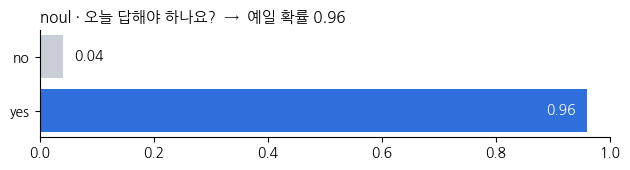

In [8]:
show(jev({"message": NOUL_MESSAGES[2]}, {"urgent": URGENT})["answers"]["urgent"], "noul · 오늘 답해야 하나요?")

## 4. choice: 어느 팀이 맡을까요?

choice는 보기 중 하나를 골라요. `criteria`에 보기 이름과 설명을 적어요(최대 255개). 딱 맞는 보기가 없을 때 고를 수 있게 **none** 같은 보기를 꼭 넣어 주세요. 답에는 고른 보기와 보기별 확률(합이 1)이 와요.

In [9]:
TEAM = {
    "type": "choice",
    "instructions": "Which team should handle `message`?",
    "criteria": {
        "billing":   "payments, refunds, invoices, duplicate charges",
        "technical": "bugs, login problems, errors, outages",
        "sales":     "pricing, plan changes, upgrades, new accounts",
        "none":      "none of the above, or not enough information",
    },
}
CHOICE_MESSAGES = NOUL_MESSAGES + ["그냥 인사드려요. 좋은 하루 보내세요!"]
for msg in CHOICE_MESSAGES:
    a = jev({"message": msg}, {"team": TEAM})["answers"]["team"]
    probs = ", ".join(f"{k} {a['probabilities'][k]:.2f}" for k in TEAM["criteria"])
    print(f"{a['choice']:<9} ({probs})  |  {msg}")

billing   (billing 1.00, technical 0.00, sales 0.00, none 0.00)  |  결제가 두 번 됐어요. 오늘 안에 환불 안 되면 카드사에 이의 신청할게요.
sales     (billing 0.00, technical 0.00, sales 1.00, none 0.00)  |  다음 달부터 요금제를 바꾸고 싶어요. 시간 나실 때 방법만 알려 주세요.
technical (billing 0.00, technical 1.00, sales 0.00, none 0.00)  |  로그인이 안 돼서 지금 수업을 못 하고 있어요! 학생들이 기다려요.
none      (billing 0.00, technical 0.00, sales 0.00, none 1.00)  |  그냥 인사드려요. 좋은 하루 보내세요!


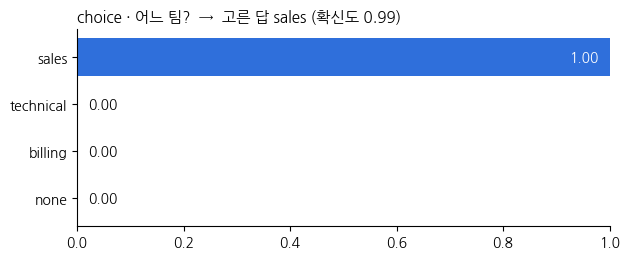

In [10]:
show(jev({"message": CHOICE_MESSAGES[1]}, {"team": TEAM})["answers"]["team"], "choice · 어느 팀?")

## 5. score: 얼마나 화가 났나요?

score는 순서 있는 단계(여기서는 0 Calm · 1 Frustrated · 2 Very angry)를 매겨요. `score`는 확률이 아니라 **단계의 기대값**이에요. 예를 들어 단계별 확률이 0.1 · 0.6 · 0.3이면 점수는 0×0.1 + 1×0.6 + 2×0.3 = 1.2예요.

In [11]:
FRUSTRATION = {
    "type": "score",
    "instructions": "How frustrated is the customer who wrote `message`?",
    "criteria": ["Calm", "Frustrated", "Very angry"],
}
SCORE_MESSAGES = [
    "영수증을 회사 이름으로 다시 받을 수 있을까요? 급한 건 아니에요.",
    "API 호출하면 500 에러가 나요. 어제부터 계속 이러네요.",
    "벌써 세 번째 문의예요. 도대체 언제 고쳐 주실 건가요? 정말 화가 나네요.",
]
for msg in SCORE_MESSAGES:
    a = jev({"message": msg}, {"frustration": FRUSTRATION})["answers"]["frustration"]
    p = a["probabilities"]
    check = sum(int(i) * v for i, v in p.items())  # 기대값을 직접 계산해 봐요
    print(f"점수 {a['score']:.2f} (직접 계산 {check:.2f})  |  {msg}")

점수 0.00 (직접 계산 0.00)  |  영수증을 회사 이름으로 다시 받을 수 있을까요? 급한 건 아니에요.
점수 0.91 (직접 계산 0.91)  |  API 호출하면 500 에러가 나요. 어제부터 계속 이러네요.
점수 1.79 (직접 계산 1.79)  |  벌써 세 번째 문의예요. 도대체 언제 고쳐 주실 건가요? 정말 화가 나네요.


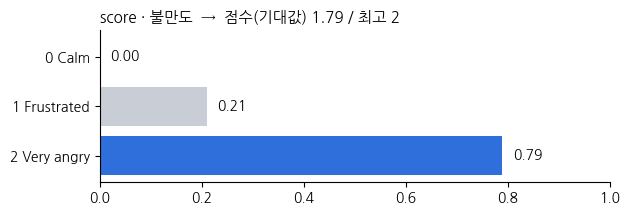

In [12]:
show(jev({"message": SCORE_MESSAGES[2]}, {"frustration": FRUSTRATION})["answers"]["frustration"], "score · 불만도")

## 6. 세 질문을 한 번에

같은 state에 질문 세 개를 한 번에 보낼 수 있어요. 세 질문은 **동시에, 서로 따로** 답해요. 그래서 team 질문은 urgent의 답을 보지 못해요. 답을 엮어서 무엇을 할지 정하는 건 **우리 코드의 몫**이에요.

먼저 따로 세 번 부를 때와 한 번에 부를 때 시간을 비교해 볼게요.

In [13]:
ALL_MSG = "벌써 세 번째 문의예요. 결제가 두 번 됐는데 오늘 안에 환불 안 되면 해지할 거예요."
state = {"message": ALL_MSG}

separate = [jev(state, {name: q}) for name, q in
            [("urgent", URGENT), ("team", TEAM), ("frustration", FRUSTRATION)]]
together = jev(state, {"urgent": URGENT, "team": TEAM, "frustration": FRUSTRATION})

print(f"따로 세 번: 합계 {sum(r['_ms'] for r in separate)} ms")
print(f"한 번에:   {together['_ms']} ms")

따로 세 번: 합계 327 ms
한 번에:   105 ms


In [14]:
a = together["answers"]
urgent_p   = a["urgent"]["noul"]
team       = a["team"]["choice"]
frustrated = a["frustration"]["score"]
print(f"긴급 {urgent_p:.2f} · 팀 {team} · 불만도 {frustrated:.2f}")

# 세 답을 엮는 규칙은 우리가 정해요.
if urgent_p >= 0.7 and frustrated >= 1.5:
    action = "사람 담당자에게 바로 연결해요"
elif team == "none":
    action = "무슨 일인지 되물어요"
else:
    action = f"{team} 팀 대기열에 넣어요"
print("결정:", action)

긴급 0.94 · 팀 billing · 불만도 1.57
결정: 사람 담당자에게 바로 연결해요


## 7. 내 문장으로 해 보기

오른쪽 입력 칸에 아무 고객 메시지나 적고 ▶ 실행해 보세요. 세 질문을 한 번에 보내고 그래프 세 개로 보여 드려요.

키가 없으면(replay 모드) 기록된 예시 문장으로만 보여 드려요.

메시지: 코난쌤 이메일로 문의드렸는데 답이 없어서 다시 연락드립니다.   (97 ms)


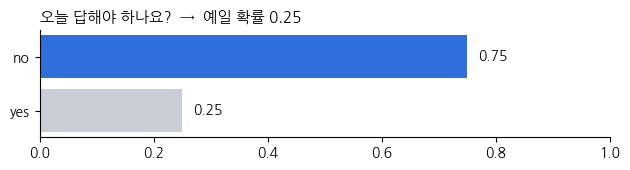

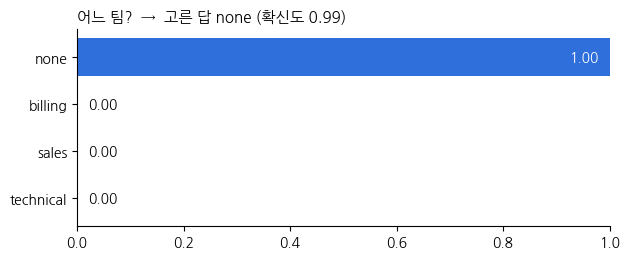

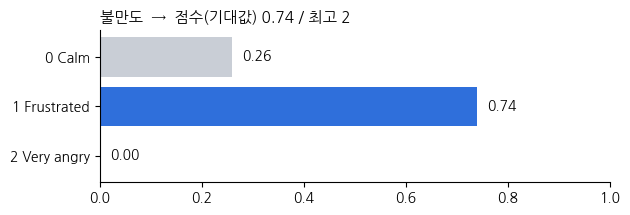

In [19]:
MY_MESSAGE = "코난쌤 이메일로 문의드렸는데 답이 없어서 다시 연락드립니다. " #@param {type:"string"}
EXAMPLE = "환불 신청한 지 일주일째인데 아무 연락이 없어요. 이번 주 안에는 꼭 처리해 주세요."
if MODE == "replay" and MY_MESSAGE != EXAMPLE:
    print("키가 없어서 예시 문장으로 보여 드릴게요. 키를 넣으면 내 문장으로 판단해요.\n")
    MY_MESSAGE = EXAMPLE

mine = jev({"message": MY_MESSAGE}, {"urgent": URGENT, "team": TEAM, "frustration": FRUSTRATION})
print(f"메시지: {MY_MESSAGE}  ({mine['_ms']} ms)")
show(mine["answers"]["urgent"], "오늘 답해야 하나요?")
show(mine["answers"]["team"], "어느 팀?")
show(mine["answers"]["frustration"], "불만도")

## 8. 팁: 지시문은 영어로 써요

state 안의 데이터(고객 메시지)는 한국어여도 괜찮지만, **질문 지시문(instructions)은 영어로 쓰는 것**이 TypeSafe 문서의 권장이에요. 같은 질문을 영어와 한국어로 써서 숫자를 비교해 볼게요.

In [20]:
import pandas as pd

URGENT_KO = {
    "type": "noul",
    "instructions": "`message`에 고객지원팀이 오늘 답장해야 하나요?",
    "criteria": {"true": "돈 문제, 장애, 지금 막혀 있는 사람", "false": "며칠 기다려도 됨"},
}
rows = []
for msg in NOUL_MESSAGES:
    en = jev({"message": msg}, {"urgent": URGENT})["answers"]["urgent"]["noul"]
    ko = jev({"message": msg}, {"urgent": URGENT_KO})["answers"]["urgent"]["noul"]
    rows.append({"메시지": msg[:30] + "…", "영어 지시문": en, "한국어 지시문": ko, "차이": round(ko - en, 2)})
pd.DataFrame(rows)

,메시지,영어 지시문,한국어 지시문,차이
0,결제가 두 번 됐어요. 오늘 안에 환불 안 되면 카드사…,0.92,0.87,-0.05
1,다음 달부터 요금제를 바꾸고 싶어요. 시간 나실 때 방…,0.10,0.13,0.03
2,로그인이 안 돼서 지금 수업을 못 하고 있어요! 학생들…,0.96,0.91,-0.05


차이가 작을 때도 많아요. 그래도 영어 지시문이 기본값이에요. 여러분의 데이터에서 꼭 이렇게 직접 재 보고 정해 주세요.

## 9. 정리

- **noul**은 예일 확률, **choice**는 보기별 확률, **score**는 단계의 기대값을 돌려줘요.
- 같은 state에 질문 여러 개를 한 번에 보내면 한 번 부른 시간에 끝나요. 질문끼리는 서로의 답을 보지 못해요.
- 확률을 행동으로 바꾸는 규칙(기준값, if 문)은 **우리 코드가** 정해요.
- 다음 노트북 `02_멀티라우터`에서는 이 판단 위에 GLM 글쓰기를 붙여 라우터를 만들어요.

아래 셀은 이번 노트북에서 부른 횟수와 비용을 보여 줘요.

In [21]:
call_summary()

Jev 호출 29번 · 합계 3.5초 · 입력 11,270토큰 → 약 $0.000473
